In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import scipy.io.wavfile

In [4]:
# path = '/kaggle/input/librispeech/LibriSpeech/test-clean/5142/36377/5142-36377-0009.wav'
# _, audio = scipy.io.wavfile.read(path)
# dataset = [audio, audio]
file = open('/kaggle/input/librispeech/LibriSpeech/CHAPTERS.TXT')
file

<_io.TextIOWrapper name='/kaggle/input/librispeech/LibriSpeech/CHAPTERS.TXT' mode='r' encoding='UTF-8'>

In [ ]:
!pip install torchaudio librosa

In [8]:
import librosa
import glob

data_path = "/kaggle/input/librispeech/"

files = glob.glob(data_path + "/**/*.flac", recursive=True)
print("Found", len(files), "files")

y, sr = librosa.load(files[0], sr=None)  
print(f"Sample rate: {sr}, Length: {len(y)/sr:.2f} seconds")


Found 10646 files
Sample rate: 16000, Length: 5.54 seconds


In [9]:
import numpy as np

def window_rms(a, window_size):
    a2 = np.square(a)
    window = np.ones(window_size) / float(window_size)
    return np.sqrt(np.convolve(a2, window, 'valid'))

window_size = int(0.02 * sr)  # 20 ms window
rms_values = window_rms(y, window_size)


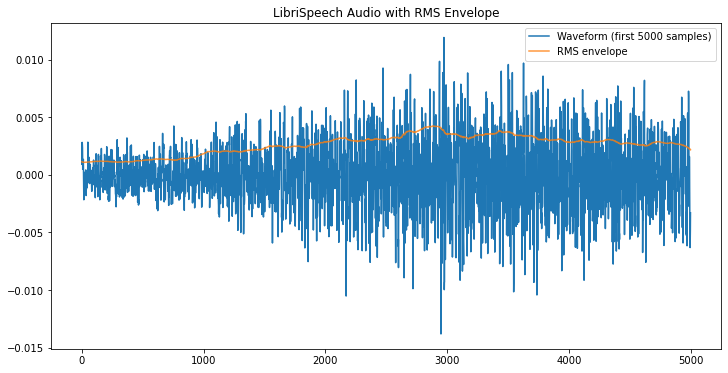

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y[:5000], label="Waveform (first 5000 samples)")
plt.plot(rms_values[:5000], label="RMS envelope", alpha=0.8)
plt.legend()
plt.title("LibriSpeech Audio with RMS Envelope")
plt.show()


In [12]:
threshold = 0.01  
pause_indices = np.where(rms_values < threshold)[0]

print("Detected", len(pause_indices), "low-energy frames (possible pauses)")


Detected 31386 low-energy frames (possible pauses)


In [13]:
import numpy as np

def short_term_energy(signal, window_size):
    squared = np.square(signal)
    window = np.ones(window_size)
    energy = np.convolve(squared, window, mode='valid')
    return energy


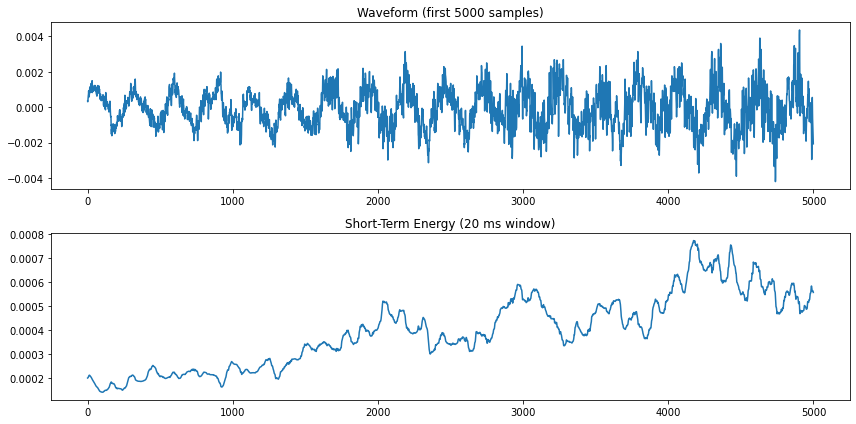

In [14]:
y, sr = librosa.load("/kaggle/input/librispeech/LibriSpeech/test-clean/1089/134686/1089-134686-0000.flac", sr=None)
window_size = int(0.02 * sr)
energy = short_term_energy(y, window_size)

plt.figure(figsize=(12, 6))
plt.subplot(2,1,1)
plt.plot(y[:5000])
plt.title("Waveform (first 5000 samples)")

plt.subplot(2,1,2)
plt.plot(energy[:5000])
plt.title("Short-Term Energy (20 ms window)")
plt.tight_layout()
plt.show()


In [15]:
import numpy as np
import matplotlib.pyplot as plt

def detect_pauses(energy, sr, window_size, threshold=0.02):
   
    # Normalize energy for easier thresholding
    energy_norm = energy / np.max(energy) 
    # Find indices below threshold
    pause_indices = np.where(energy_norm < threshold)[0]
     # Convert indices to time
    pause_times = pause_indices * (window_size / sr)
    # Group consecutive indices into intervals
    pause_segments = []
    start = None
    for i in range(len(pause_times)):
        if start is None:
            start = pause_times[i]
        if i == len(pause_times)-1 or pause_times[i+1] - pause_times[i] > (window_size/sr):
            end = pause_times[i]
            pause_segments.append((start, end))
            start = None
    
    return energy_norm, pause_segments


Detected pause segments (seconds):
(0.0, 0.06)
(0.08, 0.08)
(0.1, 0.12)
(0.14, 0.18)
(0.2, 0.24)
(0.26, 0.26)
(0.28, 0.3)
(0.32, 0.32)
(0.34, 0.36)
(0.38, 0.38)
(0.4, 0.42)
(0.44, 0.44)
(0.46, 0.48)
(0.5, 0.5)
(0.52, 0.52)
(0.54, 0.54)
(0.56, 0.58)
(0.6, 0.6)
(0.62, 0.62)
(0.64, 0.64)
(0.66, 0.66)
(0.68, 0.68)
(0.7000000000000001, 0.72)
(0.74, 0.74)
(0.76, 0.76)
(0.78, 0.78)
(0.8, 0.8)
(0.8200000000000001, 0.84)
(0.86, 0.86)
(0.88, 0.88)
(0.9, 0.9)
(0.92, 0.92)
(0.9400000000000001, 0.96)
(0.98, 0.98)
(1.0, 1.0)
(1.02, 1.02)
(1.04, 1.04)
(1.06, 1.06)
(1.08, 1.08)
(1.1, 1.1)
(1.12, 1.12)
(1.1400000000000001, 1.16)
(1.18, 1.18)
(1.2, 1.2)
(1.22, 1.22)
(1.24, 1.24)
(1.26, 1.26)
(1.28, 1.28)
(1.3, 1.3)
(1.32, 1.32)
(1.34, 1.34)
(1.36, 1.36)
(1.3800000000000001, 1.3800000000000001)
(1.4000000000000001, 1.42)
(1.44, 1.44)
(1.46, 1.46)
(1.48, 1.48)
(1.5, 1.5)
(1.52, 1.52)
(1.54, 1.54)
(1.56, 1.56)
(1.58, 1.58)
(1.6, 1.6)
(1.62, 1.62)
(1.6400000000000001, 1.6400000000000001)
(1.6600000000000001

/opt/conda/lib/python3.7/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


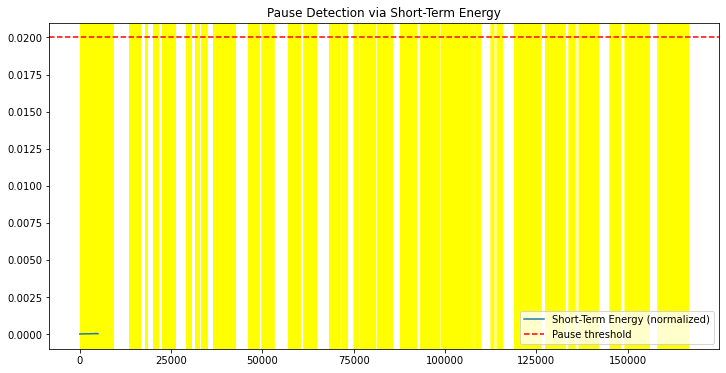

In [16]:
# Assume you already computed STE as `energy`
energy_norm, pause_segments = detect_pauses(energy, sr, window_size, threshold=0.02)
print("Detected pause segments (seconds):")
for seg in pause_segments:
    print(seg)

# Plot STE with threshold
plt.figure(figsize=(12,6))
plt.plot(energy_norm[:5000], label="Short-Term Energy (normalized)")
plt.axhline(0.02, color='red', linestyle='--', label="Pause threshold")

# Mark pauses
for (start, end) in pause_segments:
    plt.axvspan(start*sr/window_size, end*sr/window_size, color='yellow', alpha=0.3)

plt.legend()
plt.title("Pause Detection via Short-Term Energy")
plt.show()


In [17]:
import time

# Synthetic signal for testing
signal = np.random.randn(100)  # 100 samples of random audio-like data

window_size = 5  # small window for demo

# Test lengths
lengths = [1, 10, 20, 100]

results = {}

for L in lengths:
    x = signal[:L]
    
    # RMS timing
    start = time.time()
    rms_out = window_rms(x, window_size)
    rms_time = time.time() - start
    
    # STE timing
    start = time.time()
    ste_out = short_term_energy(x, window_size)
    ste_time = time.time() - start
    
    results[L] = {
        "RMS_output": rms_out,
        "STE_output": ste_out,
        "RMS_time": rms_time,
        "STE_time": ste_time
    }


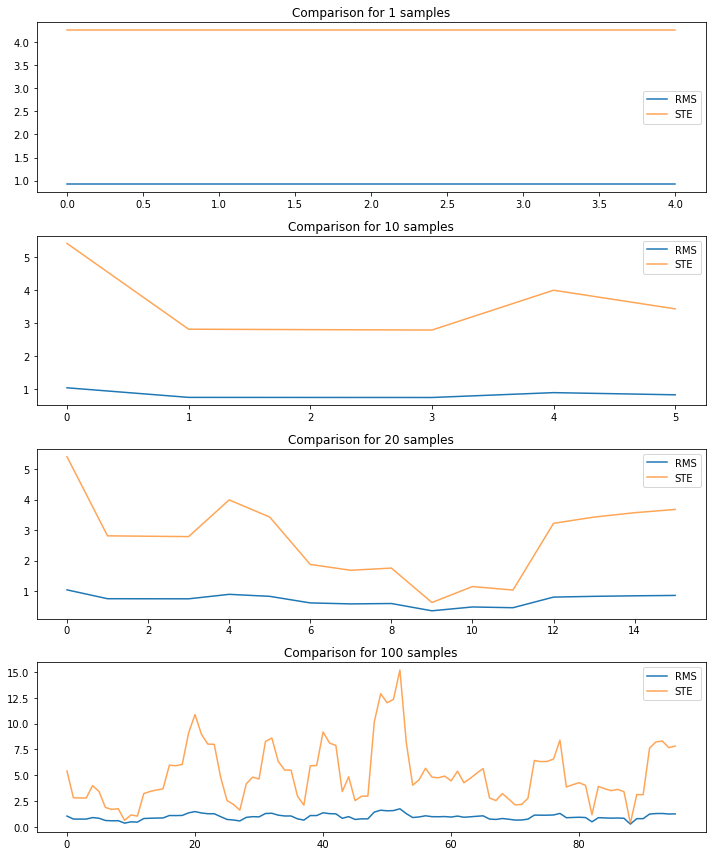

In [18]:
fig, axes = plt.subplots(len(lengths), 1, figsize=(10, 12))

for idx, L in enumerate(lengths):
    axes[idx].plot(results[L]["RMS_output"], label="RMS")
    axes[idx].plot(results[L]["STE_output"], label="STE", alpha=0.7)
    axes[idx].set_title(f"Comparison for {L} samples")
    axes[idx].legend()

plt.tight_layout()
plt.show()


In [19]:
for L in lengths:
    print(f"{L} samples -> RMS time: {results[L]['RMS_time']:.6f}s, "
          f"STE time: {results[L]['STE_time']:.6f}s")


1 samples -> RMS time: 0.000061s, STE time: 0.000045s
10 samples -> RMS time: 0.000034s, STE time: 0.000064s
20 samples -> RMS time: 0.000029s, STE time: 0.000019s
100 samples -> RMS time: 0.000031s, STE time: 0.000020s


In [20]:
def zero_crossing_rate(signal, window_size):
    """
    Compute Zero Crossing Rate (ZCR) with sliding window.
    """
    # Sign of samples
    signs = np.sign(signal)
    signs[signs == 0] = 1  # treat zeros as positive
    
    # Difference between consecutive signs
    crossings = np.abs(np.diff(signs))
    
    # Convolve with window to count crossings per frame
    window = np.ones(window_size)
    zcr = np.convolve(crossings, window, mode='valid') / window_size
    
    return zcr


In [24]:
def detect_pauses_combined(signal, sr, window_size, energy_threshold=0.02, zcr_threshold=0.1):
    # Compute STE
    energy = short_term_energy(signal, window_size)
    energy_norm = energy / np.max(energy)
    
    # Compute ZCR
    zcr = zero_crossing_rate(signal, window_size)
    
    # Align lengths (truncate to min length)
    min_len = min(len(energy_norm), len(zcr))
    energy_norm = energy_norm[:min_len]
    zcr = zcr[:min_len]
    
    # Pause condition: low energy AND low ZCR
    pause_mask = (energy_norm < energy_threshold) & (zcr < zcr_threshold)
    
    # Convert to time intervals
    pause_indices = np.where(pause_mask)[0]
    pause_times = pause_indices * (window_size / sr)
    
    # Group consecutive frames
    pause_segments = []
    start = None
    for i in range(len(pause_times)):
        if start is None:
            start = pause_times[i]
        if i == len(pause_times)-1 or pause_times[i+1] - pause_times[i] > (window_size/sr):
            end = pause_times[i]
            pause_segments.append((start, end))
            start = None
    
    return energy_norm, zcr, pause_segments


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
/opt/conda/lib/python3.7/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


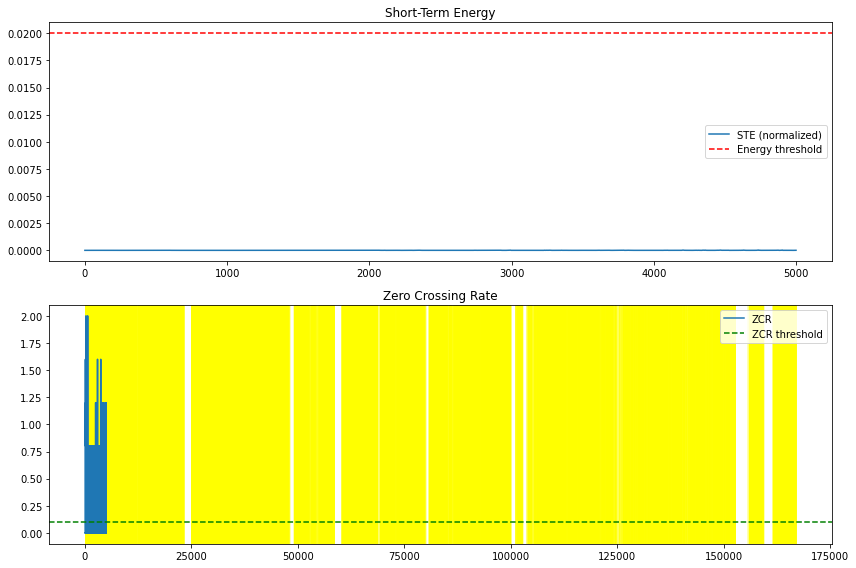

In [25]:
energy_norm, zcr, pause_segments = detect_pauses_combined(y, sr, window_size)

plt.figure(figsize=(12,8))

plt.subplot(2,1,1)
plt.plot(energy_norm[:5000], label="STE (normalized)")
plt.axhline(0.02, color='red', linestyle='--', label="Energy threshold")
plt.legend()
plt.title("Short-Term Energy")

plt.subplot(2,1,2)
plt.plot(zcr[:5000], label="ZCR")
plt.axhline(0.1, color='green', linestyle='--', label="ZCR threshold")
plt.legend()
plt.title("Zero Crossing Rate")

# Highlight pauses
for (start, end) in pause_segments:
    plt.axvspan(start*sr/window_size, end*sr/window_size, color='yellow', alpha=0.3)

plt.tight_layout()
plt.show()


In [26]:
import numpy as np
import librosa

def spectral_entropy(signal, sr, window_size):
    """
    Compute spectral entropy with sliding window.
    """
    # Frame the signal
    frames = librosa.util.frame(signal, frame_length=window_size, hop_length=window_size//2).T
    
    entropy_values = []
    for frame in frames:
        # Compute power spectrum
        spectrum = np.abs(np.fft.rfft(frame))**2
        spectrum /= np.sum(spectrum) + 1e-12  # normalize
        
        # Shannon entropy
        entropy = -np.sum(spectrum * np.log2(spectrum + 1e-12))
        entropy_values.append(entropy)
    
    return np.array(entropy_values)


In [28]:
def detect_pauses_robust(signal, sr, window_size,
                         energy_threshold=0.02,
                         zcr_threshold=0.1,
                         entropy_threshold=4.0):
    # Compute STE
    energy = short_term_energy(signal, window_size)
    energy_norm = energy / np.max(energy)
    
    # Compute ZCR
    zcr = zero_crossing_rate(signal, window_size)
    
    # Compute Spectral Entropy
    entropy = spectral_entropy(signal, sr, window_size)
    
    # Align lengths
    min_len = min(len(energy_norm), len(zcr), len(entropy))
    energy_norm = energy_norm[:min_len]
    zcr = zcr[:min_len]
    entropy = entropy[:min_len]
    
    # Pause condition: low energy, low ZCR, high entropy
    pause_mask = (energy_norm < energy_threshold) & (zcr < zcr_threshold) & (entropy > entropy_threshold)
    
    # Convert to time intervals
    pause_indices = np.where(pause_mask)[0]
    pause_times = pause_indices * (window_size / sr)
    
    # Group consecutive frames
    pause_segments = []
    start = None
    for i in range(len(pause_times)):
        if start is None:
            start = pause_times[i]
        if i == len(pause_times)-1 or pause_times[i+1] - pause_times[i] > (window_size/sr):
            end = pause_times[i]
            pause_segments.append((start, end))
            start = None
    
    return energy_norm, zcr, entropy, pause_segments


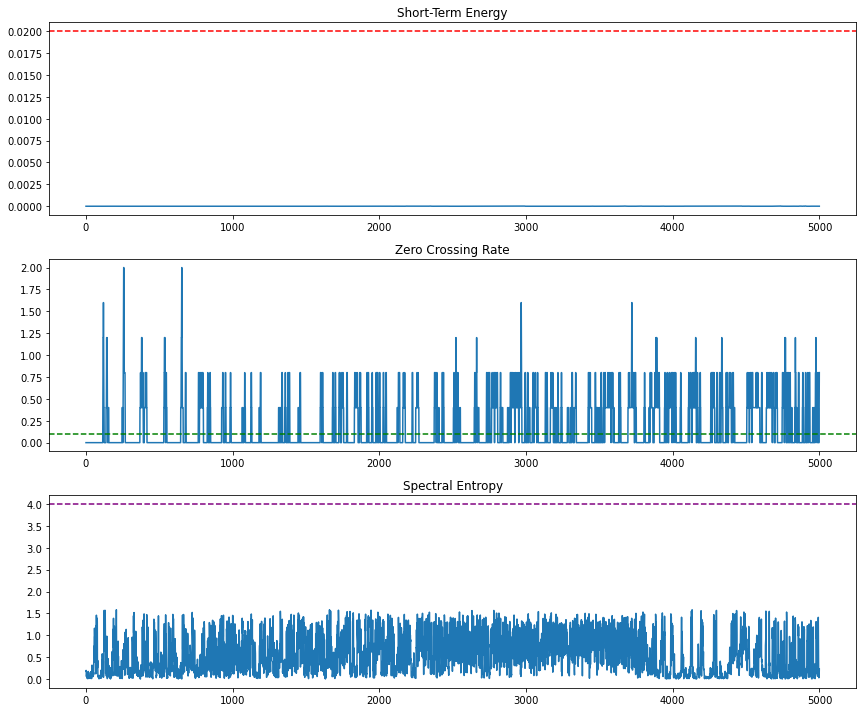

In [29]:
energy_norm, zcr, entropy, pause_segments = detect_pauses_robust(y, sr, window_size)

plt.figure(figsize=(12,10))

plt.subplot(3,1,1)
plt.plot(energy_norm[:5000], label="STE (normalized)")
plt.axhline(0.02, color='red', linestyle='--')
plt.title("Short-Term Energy")

plt.subplot(3,1,2)
plt.plot(zcr[:5000], label="ZCR")
plt.axhline(0.1, color='green', linestyle='--')
plt.title("Zero Crossing Rate")

plt.subplot(3,1,3)
plt.plot(entropy[:5000], label="Spectral Entropy")
plt.axhline(4.0, color='purple', linestyle='--')
plt.title("Spectral Entropy")

# Highlight pauses
for (start, end) in pause_segments:
    plt.axvspan(start*sr/window_size, end*sr/window_size, color='yellow', alpha=0.3)

plt.tight_layout()
plt.show()
